# Практична робота №2
**Тема:** Бінарна класифікація

## Мета роботи
Закріпити основні поняття використання моделі бінарної класифікації в машинному навчанні.

Завдання:

1.	Ознайомитеся з набором даних, що містить вимірювання, отримані з зображень двох видів турецького рису.

2.	Створіть бінарний класифікатор для розподілу зерен рису на два види.

3.	Оцініть ефективність моделі.




**Хід роботи**

Для виконання завдання будемо використовувати файл з даними, який доступный за посиланням: https://www.kaggle.com/datasets/muratkokludataset/rice-dataset-commeo-and-osmancik

В ньому розташовані дані про 2 види рису Commeo and Osmancik

Перегляньте, яка інформація там є:

Area: повертає кількість пікселів у межах рисового зерна.

Perimeter: обчислює окружність шляхом обчислення відстані між пікселями навколо меж рисового зерна.

Major Axis Length: це найдовша лінія, яку можна накреслити на рисовому зерні, тобто відстань головної осі.

Minor Axis Length: дає найкоротша лінія, яку можна намалювати на рисовому зерні, тобто мала відстань по осі.

Eccentricity: він вимірює, наскільки округлим є еліпс, який має ті самі моменти, що й рисове зерно.

Convex Area: повертає кількість пікселів найменшої опуклої оболонки області, утвореної рисовим зерном.

Extent: повертає співвідношення області, утвореної рисовим зерном, до пікселів обмежувальної рамки

Класи: Коммео і Османчик



**Крок 1.** Імпортуйте необхідні бібліотеки

In [10]:
# Робота з даними
import pandas as pd
import numpy as np

# Візуалізація
import matplotlib.pyplot as plt
import seaborn as sns

# Машинне навчання
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Класифікаційні моделі
from sklearn.neighbors import KNeighborsClassifier    # KNN
from sklearn.tree import DecisionTreeClassifier, plot_tree # дерево рішень
from sklearn.naive_bayes import GaussianNB            # наївний Байєс

# Метрики оцінки якості
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

**Крок 2**. Завантажте дані з хмари

In [5]:
# Пряме посилання на датасет (Cammeo vs Osmancik)
df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/Rice_Cammeo_Osmancik.csv")

# Перевірка
print(df.shape)
print(df.head())
print(df['Class'].value_counts())

(3810, 8)
    Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  15231  525.578979         229.749878          85.093788      0.928882   
1  14656  494.311005         206.020065          91.730972      0.895405   
2  14634  501.122009         214.106781          87.768288      0.912118   
3  13176  458.342987         193.337387          87.448395      0.891861   
4  14688  507.166992         211.743378          89.312454      0.906691   

   Convex_Area    Extent   Class  
0        15617  0.572896  Cammeo  
1        15072  0.615436  Cammeo  
2        14954  0.693259  Cammeo  
3        13368  0.640669  Cammeo  
4        15262  0.646024  Cammeo  
Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


**Крок 3.** Підготуємо набори даних для класифікації

Виділемо ознаки та ціль: X — числові характеристики зерна, y — клас (Cammeo чи Osmancik).

Розділемо дані: тренувальні (80%) для навчання, тестові (20%) для перевірки.

Відмасштабуємо ознаки: щоб усі параметри були в одному діапазоні (важливо для логістичної регресії та KNN).

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Вибираємо ознаки (усі числові стовпці, крім 'Class')
X = df.drop(columns=['Class'])
y = df['Class']   # цільова змінна: Cammeo / Osmancik

# 2. Розділення на тренувальні та тестові дані
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% даних для тесту
    random_state=42,      # фіксуємо випадковість
    stratify=y            # зберігаємо пропорцію класів
)

# 3. Масштабування ознак (рекомендовано для лінійних моделей)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Розмір тренувальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)

Розмір тренувальної вибірки: (3048, 7)
Розмір тестової вибірки: (762, 7)


**Крок 4. Класифікація за моделлю KNN**

Почнемо з найпростішого класифікатора — K‑Nearest Neighbors (KNN). Він працює за принципом: новий об’єкт відноситься до того класу, якому належить більшість його найближчих сусідів.

Пояснення
n_neighbors=5 → модель дивиться на 5 найближчих сусідів і відносить об’єкт до більшості.

Accuracy → частка правильних передбачень.

Classification report → precision, recall, F1 для кожного класу.

Confusion matrix → показує, де саме модель плутає Cammeo та Osmancik.

In [7]:
# 1. Створюємо модель KNN
knn = KNeighborsClassifier(n_neighbors=5)  # параметр k = 5

# 2. Навчаємо модель на тренувальних даних
knn.fit(X_train_scaled, y_train)

# 3. Робимо прогноз на тестових даних
y_pred_knn = knn.predict(X_test_scaled)

# 4. Оцінюємо якість
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.9094488188976378

Classification report:
               precision    recall  f1-score   support

      Cammeo       0.91      0.88      0.89       326
    Osmancik       0.91      0.93      0.92       436

    accuracy                           0.91       762
   macro avg       0.91      0.91      0.91       762
weighted avg       0.91      0.91      0.91       762


Confusion matrix:
 [[287  39]
 [ 30 406]]


**Інтерпретація**
Accuracy = 0.9094. Accuracy показує частку правильних передбачень серед усіх прикладів.У нашому випадку модель правильно класифікувала ~91% зерен рису.
Це досить високий показник, але він не завжди відображає баланс між класами (тому дивимося на precision/recall).

Для класу Cammeo:

Precision = 0.91 → серед усіх зерен, які модель позначила як Cammeo, 91% справді Cammeo.

Recall = 0.88 → модель знайшла 88% усіх Cammeo, але 12% пропустила (помилково віднесла до Osmancik).

F1 = 0.89 → збалансований показник точності та повноти.

Для класу Osmancik:

Precision = 0.91 → серед усіх передбачених Osmancik, 91% справді Osmancik.

Recall = 0.93 → модель знайшла 93% усіх Osmancik, лише 7% пропустила.

F1 = 0.92 → дуже хороший баланс.

Загалом:

Macro avg = 0.91 → середнє значення метрик для обох класів.

Weighted avg = 0.91 → середнє з урахуванням кількості прикладів у кожному класі.

Це означає, що модель працює стабільно для обох сортів рису.

Confusion Matrix:

Рядок 1 (Cammeo):287 → правильно класифіковані як Cammeo.39 → помилково класифіковані як Osmancik.

Рядок 2 (Osmancik):30 → помилково класифіковані як Cammeo.406 → правильно класифіковані як Osmancik.

Висновок: модель трохи частіше плутає Cammeo з Osmancik, ніж навпаки.

**Крок 5. Дерево рішень**
Побудуємо ту ж саму класифікацію іншим методом.

DecisionTreeClassifier будує дерево правил для класифікації. Воно інтуїтивно зрозуміле: будує правила типу «якщо довжина > 10 → Osmancik».

max_depth=5 → обмежує складність дерева, щоб уникнути перенавчання.


In [8]:
# 1. Створюємо модель дерева рішень
dt = DecisionTreeClassifier(random_state=42, max_depth=5)  # обмежимо глибину для простоти

# 2. Навчаємо модель
dt.fit(X_train_scaled, y_train)

# 3. Прогнозуємо на тестових даних
y_pred_dt = dt.predict(X_test_scaled)

# 4. Оцінка якості
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.9081364829396326

Classification report:
               precision    recall  f1-score   support

      Cammeo       0.89      0.90      0.89       326
    Osmancik       0.92      0.92      0.92       436

    accuracy                           0.91       762
   macro avg       0.91      0.91      0.91       762
weighted avg       0.91      0.91      0.91       762


Confusion matrix:
 [[293  33]
 [ 37 399]]


Зробіть інтерпретацію результатів моделювання самостійно:


**Крок 6**.Візуалізуємо дерево рішень

[Text(0.5, 0.875, 'Major_Axis_Length <= 0.194\ngini = 0.49\nsamples = 3048\nvalue = [1304, 1744]\nclass = Osmancik'),
 Text(0.25, 0.625, 'Major_Axis_Length <= -0.129\ngini = 0.122\nsamples = 1767\nvalue = [115, 1652]\nclass = Osmancik'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Major_Axis_Length <= -0.43\ngini = 0.056\nsamples = 1553\nvalue = [45, 1508]\nclass = Osmancik'),
 Text(0.0625, 0.125, 'gini = 0.019\nsamples = 1282\nvalue = [12, 1270]\nclass = Osmancik'),
 Text(0.1875, 0.125, 'gini = 0.214\nsamples = 271\nvalue = [33, 238]\nclass = Osmancik'),
 Text(0.375, 0.375, 'Major_Axis_Length <= 0.043\ngini = 0.44\nsamples = 214\nvalue = [70, 144]\nclass = Osmancik'),
 Text(0.3125, 0.125, 'gini = 0.342\nsamples = 105\nvalue = [23, 82]\nclass = Osmancik'),
 Text(0.4375, 0.125, 'gini = 0.491\nsamples = 109\nvalue = [47, 62]\nclass = Osmancik'),
 Text(0.75, 0.625, 'Perimeter <= 0.378\ngini = 0.133\nsamples = 1281\nvalue = [1189, 92]\nclass = Cammeo'),
 Text(0.625, 0.75, '  False')

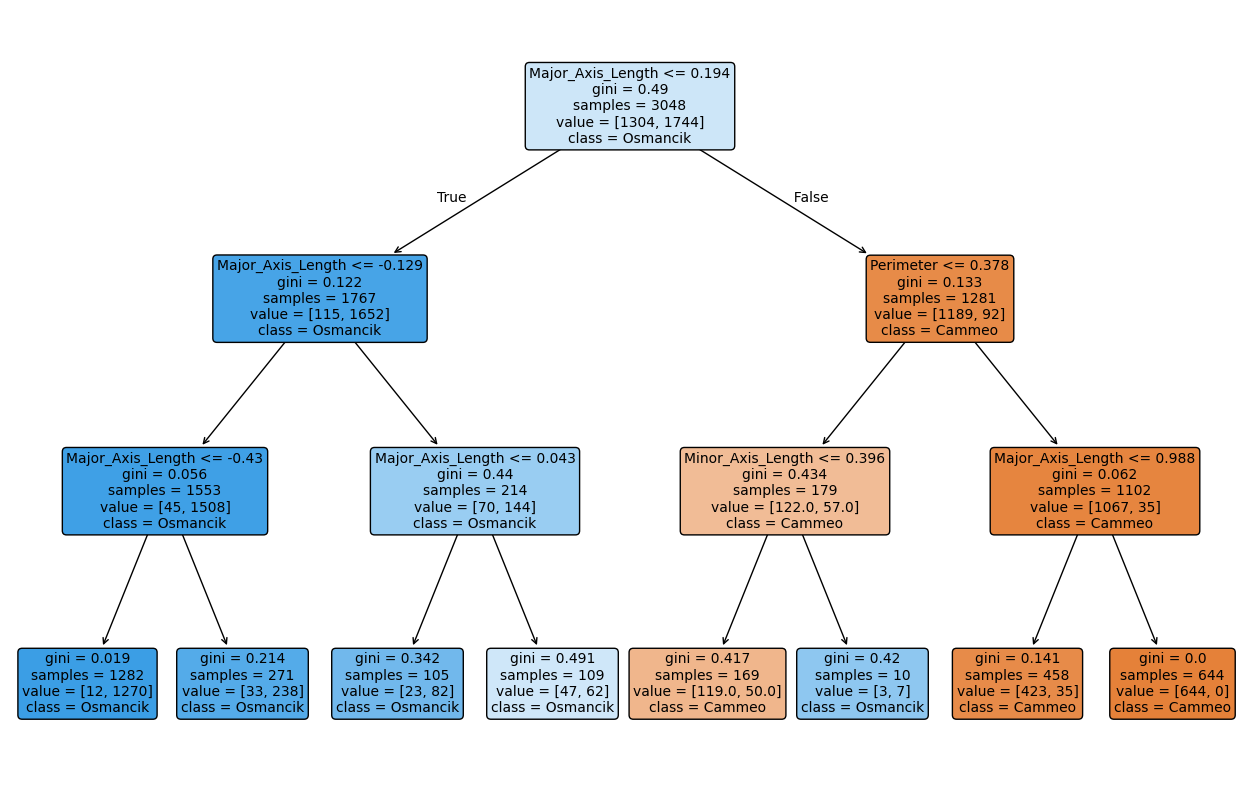

In [11]:
# Створюємо та навчаємо дерево рішень
dt = DecisionTreeClassifier(random_state=42, max_depth=3)  # обмежимо глибину для читабельності
dt.fit(X_train_scaled, y_train)

# Візуалізація дерева
plt.figure(figsize=(16,10))
plot_tree(
    dt,
    feature_names=X.columns,      # назви ознак
    class_names=dt.classes_,      # назви класів (Cammeo, Osmancik)
    filled=True,                  # кольорове заповнення вузлів
    rounded=True,                 # округлені вузли
    fontsize=10
)

**Завдання для самостійного виконання**

Побудуйте модель класифікації на основі Gaussian Naive Bayes (nb = GaussianNB())

Порівняйте результати трьох моделей.

Яка модель має найвищу точність?

In [ ]:
#Тут має бути Ваш код


Тут мають бути Ваші висновки